# **Using Uproot to Rediscover the Higgs Boson in Atlas Open Data Example Notebook**

**Oliver Alban**

**5/25/2026**

This notebook shows all three activities combined into one notebook. Much of the code is the same as was shown in the paper, some is different to make the notebook more flexible. Create your notebook(s) in whatever way works best for you

In [5]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import matplotlib.text
import sys

## **Activity 1: Z Peak**

### Accessing the Data

This cell only needs to be run on your computer one time ever 

In [ ]:
import sys
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

These cells must be executed everytime you restart the kernel

In [6]:
import atlasopenmagic as atom
atom.available_releases()
# you can change the release here
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...


Available releases:
2016e-8tev           2016 Open Data for education release of 8 TeV proton-proton collisions (https://opendata.cern.ch/record/3860).
2020e-13tev          2020 Open Data for education release of 13 TeV proton-proton collisions (https://cern.ch/2r7xt).
2024r-pp             2024 Open Data for research release for proton-proton collisions (https://opendata.cern.record/80020).
2024r-hi             2024 Open Data for research release for heavy-ion collisions (https://opendata.cern.ch/record/80035).
2025e-13tev-beta     2025 Open Data for education and outreach beta release for 13 TeV proton-proton collisions (https://opendata.cern.ch/record/93910).
2025r-evgen-13tev    2025 Open Data for research release for event generation at 13 TeV (https://opendata.cern.ch/record/160000).
2025r-evgen-13p6tev  2025 Open Data for research release for event generation at 13.6 TeV (https://opendata.cern.ch/record/160000).


Fetching datasets:   0%| | 0/374 [00:00<?, ?datasets/s

Fetching datasets: 100%|█| 374/374 [00:00<00:00, 395.4

Fetching datasets: 100%|█| 374/374 [00:00<00:00, 392.8


✓ Successfully cached 374 datasets.


Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [7]:
# the skim only pulls out events with 2 to 4 leptons
skim = '2to4lep'
files_list = atom.get_urls('data', skim, protocol = 'https', cache=True)

Below, the number of files has been reduced to num_files because it takes too much time to open and analyze files. You only need one file to get a distinct Z peak so opening all 16 would be uneccessary.

In [8]:
num_files = 1 # the number of files that we want to analyze

# an empty array that we can append to in the for loop
leps = []

for file in files_list[:num_files]:
    print(f'Analyzing file:  {file} ({files_list.index(file)+1}/{len(files_list)})')

    # open file and turn it into a structured array
    analysis = uproot.open(file + ':analysis')
    attributes = ['pt','eta','phi','e','charge','flavor','isTightID']
    aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                               'charge':'lep_charge','flavor':'lep_type','isTightID':'lep_isTightID'}
    leps_partial = analysis.arrays(attributes, aliases = aliases_dict)

    # concatenate current structured array onto previous structured arrays
    leps = np.concatenate([leps,leps_partial],axis=0)
print(f'{num_files} file(s) opened and added to leps')

Analyzing file:  simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodD.2to4lep.root (1/16)


1 file(s) opened and added to leps


### Remove All Non-Z Bosons

Filter 'leps' to increase the likelyhood that a given event is a Z Boson
Our conditions for our cut are:
1. the 2 leptons are of opposite charges
2. the 2 leptons are of the same flavor
3. the 2 leptons are both tight

In [9]:
# sort leps in decending order by pt and remove all but the two highest pt leps
sorter = np.argsort(leps.pt,axis=1)[:,::-1] # an array of indices that can be applied to the whole of leps
leps = leps[sorter][:,:2]

In [10]:
# create the cuts to leps
charge_cut = leps.charge[:,0] + leps.charge[:,1] == 0
flavor_cut = leps.flavor[:,0] == leps.flavor[:,1]
tight_cut = (leps.isTightID[:,0]) & (leps.isTightID[:,1])

### Find the Masses of the Z Bosons

Mass is calculated using the formula: $m=\sqrt{E^2-\textbf{p}\cdot\textbf{p}}$

In [11]:
# multiply arrays component-wise to get components of p that can be summed
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

# create all components of the 4 momentum of the Z boson in each event
sum_px = px[:,0] + px[:,1]
sum_py = py[:,0] + py[:,1]
sum_pz = pz[:,0] + pz[:,1]
sum_e = leps.e[:,0] + leps.e[:,1]

# Use the invarient quantity of the momentum 4 vector, converted to units of GeV
masses = np.sqrt(np.abs(sum_e**2-sum_px**2-sum_py**2-sum_pz**2))

### Plotting Z Masses

Below is the application of the Z cuts to masses. Try different combinations of cuts and see how the plot changes.

In [13]:
masses = masses[charge_cut & flavor_cut & tight_cut]

Below is the plotting of Zs, try changing some of the initial parameters and see how the plot changes

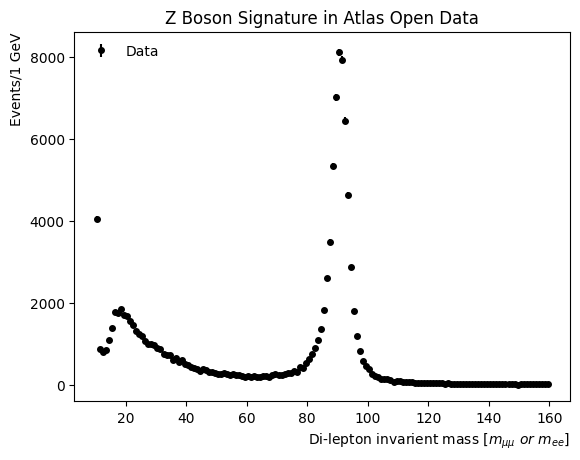

In [14]:
# initial parameters
x_min, x_max = 10,160
bin_width = 1
bin_edges = np.arange(start = x_min, stop = x_max+1, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2
counts, _ = np.histogram(masses, bins=bin_edges)
count_errors = np.sqrt(counts)

#plot
plt.errorbar(x = bin_centers, y = counts, yerr = count_errors, fmt = 'ko', label = 'Data', markersize = 4)
plt.title('Z Boson Signature in Atlas Open Data')
plt.xlabel('Di-lepton invarient mass [${m_{\mu\mu} \ or \ m_{ee}}$]', x=1, horizontalalignment = 'right')
plt.ylabel('Events/' + str(bin_width) + ' GeV', y=1, horizontalalignment = 'right')
plt.legend(frameon = False, loc = 'upper left')
plt.show()

## **Activties 2 & 3: Higgs Peak**

### Obtaining the Data

#### Option 1: Monte Carlo Simulation

This first option results in a very distinct Higgs peak. Start here if you are a beginner.

The os library is only needed to chage the current working directory to simplify file names. If these lines were omitted, the file name would have to be 'Downloads/CernOpenData/file_name:mini'.

In [2]:
import os

In [3]:
# check current working directory
os.getcwd()

'C:\\Users\\OWAOS'

In [4]:
# change directory to the location of the root files
os.chdir('Downloads/CernOpenData')

In [5]:
# open Monte Carlo Simulation
mini = uproot.open('mc_160155.ggH125_ZZ4lep.root:mini')

# turn file into a structured array
attributes = ['pt','eta','phi','e','charge','flavor']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_E',
                           'charge':'lep_charge','flavor':'lep_type'}
leps = mini.arrays(attributes, aliases = aliases_dict)

# remove all events with less than 4 leptons from leps
# ns is seperate from leps so that leps may be sorted more easily by transverse momentum
# ns is of a different shape than all other fields
ns = mini.arrays(['n'], aliases = {'n':'lep_n'})
leps = leps[ns.n>=4]

# convert leps.e and leps.pt to units of GeV
leps['e'] = leps.e/1000
leps['pt'] = leps.pt/1000

# tight condition with all values set to true. This is only needed so that this notebook can analyze
# both real and simulated data. Real data has lep_isTightID. Simulated data does not.
tight = np.ones((len(leps.pt),4))

### Option 2: Real Data

The second option results in a far less distinct peak. It is good to play with the selections to see the peak with and without the background.

In [ ]:
import atlasopenmagic as atom
atom.available_releases()
# you can change the release here
atom.set_release('2025e-13tev-beta')

In [22]:
# this skim returns only events with 4 or more leptons per event
skim = "4lep"
files_list = atom.get_urls('data', skim, protocol='https', cache=True)

In [23]:
# empty array to be appended to in the for loop
leps = []

for file in files_list:
    print(f'Analyzing file: {file} ({files_list.index(file)+1}/{len(files_list)})')

    # open files and turn into a structured array
    analysis = uproot.open(file +':analysis')
    attributes = ['pt','eta','phi','e','charge','flavor','tight']
    aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
    leps_partial = analysis.arrays(attributes, aliases = aliases_dict)

    # append the current structured array to all previous structured arrays
    leps = np.concatenate([leps,leps_partial], axis=0)
print('Completed processing all files')

Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root (1/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root (2/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodF.4lep.root (3/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodG.4lep.root (4/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodH.4lep.root (5/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodJ.4lep.root (6/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data16_periodA.4lep.root (7/16)
Analyzing fil

### Convert Data Into 3D Array

vecs is a 3D array that can be sliced in different ways allowing us to form all possible Z Boson combinations and then all possible Higgs Boson combinations. I have defined it as an initial 'all zeros' event that will be removed by the cuts later. The advantage of doing this is that we can use the cell below it to append however many files we want to vecs.

It can sliced like so: vecs[attribute, event #, lep #] The attribute indices are in the order they were defined

0. E (energy) 
1. px (momentum in the x direction)
2. py (... y ...)
3. pz (... z ...)
4. leps.charge (charge)
5. leps.flavor (flavor)
6. leps.isTightID (TightID)

- vecs[0, :, :] Would return a 2D array of all the energies for each lepton in each event
- vecs[1, :, :] would likewise return a 2D array of all pxs
- vecs[:, 0, :] Would return all attributes for all 4 leptons for the first lepton event
- vecs[:, :, 0] Would return all attributes for the first lepton in each lepton event

Storing our data like this has pros and cons. It is useful here because it can be sliced in whichever way I please, it is also in a way disadvantageous because of how abstract it is, none of the attributes are labeled like they were in the ROOT file or in the dict that Uproot created.

In [6]:
# sort leptons by transverse momentum, reduce number of leptons per event to 4
leps = leps[np.argsort(leps.pt, axis=1)[:,::-1]][:,:4]

# convert pt into px, py, pz
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

# this line keeps the naming consistent for both file options
if 'tight' in leps.fields:
    tight = leps.tight

# Create an 3D Array of lepton attributes that can be easily sliced and
# added to form all possible Z Boson combinations
vecs = np.array([leps.e,px,py,pz,leps.charge,leps.flavor,tight])

Above, we have a somewhat complicated looking sorting expression. Its purpose is to sort the leptons by transverse momentum. It works like this:

- Use np.argsort(leps.pt, axis=1) to create a map of how to sort leps.pt from least to greatest for each event
- add the slice [:,::-1] to flip all of the rows and get a map of leps.pt from greatest to least.
- apply our map to all of leps so that each attribute is altered in the same way.
- add the slice [:,:4] to throw away any additional leptons after the 4 highest pt leptons

### Obtaining all Possible Z Masses

Below we are obtaining all possible combinations of leptons that could have yeilded a Z Boson. The order in which Zs is defined does matter. Organizing it this way ensures that corresponding on and off shell Z Bosons will be in the same array index when we constuct shell_cut.

Rather than making a 2D array of all the possible Zs, I have made a 3D array of all possible Zs so that the event indices are preserved. When we plot the Higgs Bosons, we want to ensure that we are not double counting leptons

In [7]:
Z0 = vecs[:,:,0] + vecs[:,:,1]
Z1 = vecs[:,:,0] + vecs[:,:,2]
Z2 = vecs[:,:,0] + vecs[:,:,3]
Z3 = vecs[:,:,1] + vecs[:,:,2]
Z4 = vecs[:,:,1] + vecs[:,:,3]
Z5 = vecs[:,:,2] + vecs[:,:,3]
Zs = np.array([Z0,Z1,Z2,Z5,Z4,Z3])

Below are cuts based on Z like behavior.

In [8]:
Z_charge_cut = Zs[:,4] == 0
Z_flavor_cut = (Zs[:,5] == 22) | (Zs[:,5] == 26)
Z_tight_cut = Zs[:,6] == 2

Zmass is a 2D array of the masses of all possible Z bosons. It will be used to determine on and off shell Z Bosons.

In [9]:
Z_mass = np.sqrt(np.abs(Zs[:,0,:]**2-Zs[:,1,:]**2-Zs[:,2,:]**2-Zs[:,3,:]**2))

### Plotting all Possible Z Masses

Below is the application of the Z cuts to Z mass. The code inserts a zero at all indicies contianing the value False. Try different combinations of cuts and see how the plot changes.

In [10]:
Z_mass[np.invert(Z_charge_cut & Z_flavor_cut & Z_tight_cut)] = 0

To plot Zmass, we must convert a 2D array into a 1D array and then remove all zero vectors (which stand for invalid Z Bosons).

In [29]:
Z_masses = np.ndarray.flatten(Z_mass)
Z_masses = Z_masses[Z_masses != 0]

Below is the plotting of Z_masses, try changing some of the initial parameters and see how the plot changes

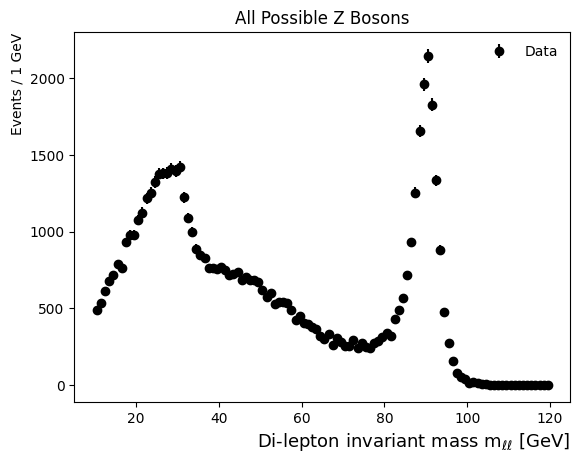

In [30]:
# x-axis range of the plot
xmin = 10 #GeV
xmax = 120 #GeV

# Histogram bin setup
bin_width = 1 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(Z_masses, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Di-lepton invariant mass $\mathrm{m_{\ell\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('All Possible Z Bosons')
axs.legend(frameon = False)
plt.show()

### Obtaining Higgs Masses

All possible Z combinations yeilding a Higgs without double counting leptons are:

Z0 -> lep0 and lep1

Z1 -> lep0 and lep2

Z2 -> lep0 and lep3

Z3 -> lep1 and lep2

Z4 -> lep1 and lep3

Z5 -> lep2 and lep3

Higgs0 -> Z0 and Z5 -> lep0, lep1, lep2, and lep3

Higgs1 -> Z1 and Z4 -> lep0, lep2, lep1, and lep3

Higgs2 -> Z2 and Z3 -> lep0, lep3, lep1, and lep2

If Z0 is an on shell Z, then the off shell Z **has to be** Z5 and likewise with Z3 and Z4 to form a valid Higgs. This is why the array Zs was defined in such a specific order, when the array is split in half (first 3 Zs and last 3 Zs), every possible Z pair will have equivalent indicies in both arrays (the on shell will be in the same spot that the off shell is in in the other array.

Because of the way we defined Zs, creating the Higgs array is simply the addition of the two halfs.

In [14]:
Higgs = Zs[:3] + Zs[3:]

Below is the shell_cut declaration. Like previously discussed, it only works because of the order in which Zs was defined. The mass constraints come from an over simplified version of the selections in the Higgs Boson discovery paper.

In [15]:
# split the array into two halfs
Z_mass_upper = Z_mass[:3]
Z_mass_lower = Z_mass[3:]

# define our mass constraints
Z_on_min, Z_on_max = 50, 106
Z_off_min, Z_off_max = 17.5, 115

# return true for all indices where a on\off shell pair exists
Z_up_is_on = (Z_mass_upper > Z_on_min) & (Z_mass_upper < Z_on_max)
Z_up_is_off = (Z_mass_upper > Z_off_min) & (Z_mass_upper < Z_off_max)
Z_low_is_on = (Z_mass_lower > Z_on_min) & (Z_mass_lower < Z_on_max)
Z_low_is_off = (Z_mass_lower > Z_off_min) & (Z_mass_lower < Z_off_max)

shell_cut = (Z_up_is_on & Z_low_is_off) | (Z_up_is_off & Z_low_is_on)

Below are the application of the Z cuts to the Higgs array. There needs to exist a valid Z in both the upper and lower half of the array Zs for there to exist a valid Higgs.

In [16]:
H_charge_cut = Z_charge_cut[:3] & Z_charge_cut[3:]
H_flavor_cut = Z_flavor_cut[:3] & Z_flavor_cut[3:]
H_tight_cut = Z_tight_cut[:3] & Z_tight_cut[3:]

The final array of Higgs Masses will be one dimensional, since there can only be one Higgs created per event. To convert our 2D selections to a 1D selection, we will use the | operator to combine the different rows. For there to exist a valid Higgs boson in an event, only one of the rows needs to record True, so we use the | operator.

In [32]:
shell_cut_flat = shell_cut[0] | shell_cut[1] | shell_cut[2]
charge_cut_flat = H_charge_cut[0] | H_charge_cut[1] | H_charge_cut[2]
flavor_cut_flat = H_flavor_cut[0] | H_flavor_cut[1] | H_flavor_cut[2]
tight_cut_flat = H_tight_cut[0] | H_tight_cut[1] | H_tight_cut[2]

H_mass is a 1D array of Higgs masses. While there are 3 possible combinations of leptons that yield a Higgs for every event, they all yield Higgs Bosons of the same mass, so we only need to keep one row of masses.

In [33]:
H_mass = np.sqrt(np.abs(Higgs[:,0]**2-Higgs[:,1]**2-Higgs[:,2]**2-Higgs[:,3]**2))[0]

### Plotting Higgs Masses

Below is the application of the Higgs cuts to Higgs Masses. Try different combinations of the cuts to see how the plot changes.

In [34]:
H_mass = H_mass[shell_cut_flat & charge_cut_flat & flavor_cut_flat & tight_cut_flat]

Below is the plotting of H_mass, try changing some of the initial parameters and see how the plot changes

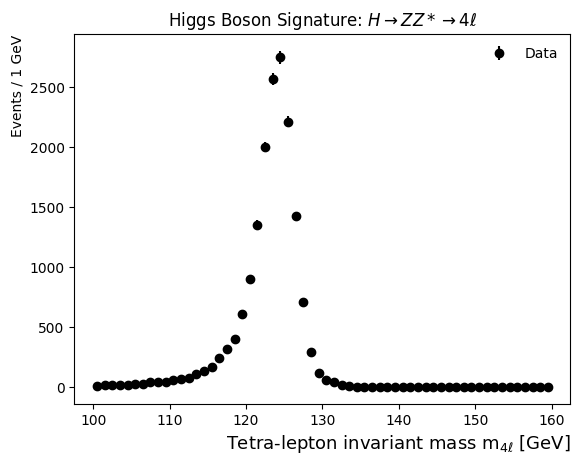

In [35]:
# x-axis range of the plot
xmin = 100 #GeV
xmax = 160 #GeV

# Histogram bin setup
bin_width = 1 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(H_mass, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Tetra-lepton invariant mass $\mathrm{m_{4\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('Higgs Boson Signature: ' + r'$H \rightarrow ZZ* \rightarrow 4\ell$')
axs.legend(frameon = False)
plt.show()